In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import joblib

In [2]:
%matplotlib inline 

In [3]:
features = ['release_speed',
            'release_spin_rate',
            'spin_axis',
            'release_extension',
            'az',
            'ax',
            'release_pos_x',
            'release_pos_z',
            'speed_diff',
            'az_diff',
            'ax_diff',
            'stand',
            'p_throws']

target = 'target'

In [4]:
seed = 1126

In [5]:
def xgb_evaluate(model, dtrain, dtest):
    train_pred = model.predict(dtrain)
    train_error = root_mean_squared_error(dtrain.get_label(), train_pred)
    test_pred = model.predict(dtest)
    test_error = root_mean_squared_error(dtest.get_label(), test_pred)

    print(f'Training RMSE: {train_error}\nTesting RMSE: {test_error}')

In [6]:
def lgb_evaluate(model, x_train, y_train, x_test, y_test):
    train_pred = model.predict(x_train)
    train_error = root_mean_squared_error(y_train, train_pred)
    test_pred = model.predict(x_test)
    test_error = root_mean_squared_error(y_test, test_pred)

    print(f'Training RMSE: {train_error}\nTesting RMSE: {test_error}')

##### Prepare Data For Models

In [7]:
all_data = pl.read_csv('./data/train_data.csv')

In [8]:
all_data = all_data.with_columns([
        pl.col("p_throws").cast(pl.Categorical)
    ])

all_data = all_data.with_columns([
        pl.col("stand").cast(pl.Categorical)
    ])

In [9]:
all_data = all_data.drop_nulls(subset = features + [target])

In [10]:
all_data = all_data.to_pandas()

In [11]:
all_data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,target,swing,pitch_type_right,avg_fastball_speed,avg_fastball_az,avg_fastball_ax,count_right,speed_diff,az_diff,ax_diff
0,FF,2021-10-03,92.3,-1.4,6.80,"Smith, Will",596019,519293,field_out,hit_into_play,...,-0.171953,True,FF,92.782745,-13.010536,-8.233451,2040,-0.482745,-1.072688,-1.474941
1,FF,2021-10-03,92.3,-1.4,6.80,"Smith, Will",596019,519293,field_out,hit_into_play,...,-0.175025,True,FF,92.782745,-13.010536,-8.233451,2040,-0.482745,-1.072688,-1.474941
2,FF,2021-10-03,92.3,-1.4,6.80,"Smith, Will",596019,519293,field_out,hit_into_play,...,-0.174317,True,FF,92.782745,-13.010536,-8.233451,2040,-0.482745,-1.072688,-1.474941
3,FF,2021-10-03,92.3,-1.4,6.80,"Smith, Will",596019,519293,field_out,hit_into_play,...,-0.174108,True,FF,92.782745,-13.010536,-8.233451,2040,-0.482745,-1.072688,-1.474941
4,SL,2021-10-03,80.6,-1.6,6.64,"Smith, Will",596019,519293,None,foul,...,-0.063749,True,FF,92.782745,-13.010536,-8.233451,2040,-12.182745,-14.358578,14.764575


In [11]:
all_x = all_data[features]
all_y = all_data[target]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(all_x, all_y, test_size = 0.2, random_state = seed)

In [13]:
print(x_train.shape)
print(x_test.shape)

(9040090, 13)
(2260023, 13)


##### XGBoost

In [14]:
d_train = xgb.DMatrix(x_train, label = y_train, enable_categorical = True)
d_test = xgb.DMatrix(x_test, label = y_test, enable_categorical = True)

In [15]:
params = {'objective': 'reg:squarederror', 'max_depth': 30, 'learning_rate': 0.05, 'eval_metric': 'rmse', 'random_state': seed, 'tree_method': 'hist'}
num_rounds = 500

In [16]:
xgb_model = xgb.train(params, d_train, num_rounds)

In [17]:
xgb_evaluate(xgb_model, d_train, d_test)

Training RMSE: 0.0029299280140548944
Testing RMSE: 0.019982581958174706


In [18]:
filename = './model_storage/xgboost_model.joblib'
joblib.dump(xgb_model, filename)
print(f"Model saved to {filename}")

Model saved to ./model_storage/xgboost_model.joblib


##### LightGBM

In [19]:
d_train = lgb.Dataset(x_train, label = y_train)
d_test = lgb.Dataset(x_test, label = y_test)

In [20]:
params = {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.02, 'random_state': seed}
num_rounds = 2000

In [21]:
lgb_model = lgb.train(params, d_train, num_rounds)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2604
[LightGBM] [Info] Number of data points in the train set: 9040090, number of used features: 13
[LightGBM] [Info] Start training from score 0.000007


In [22]:
lgb_evaluate(lgb_model, x_train, y_train, x_test, y_test)

Training RMSE: 0.2143545226037828
Testing RMSE: 0.214344882371529


In [23]:
filename = './model_storage/lightgbm_model.joblib'
joblib.dump(lgb_model, filename)
print(f"Model saved to {filename}")

Model saved to ./model_storage/lightgbm_model.joblib


### Analysis

In [14]:
import pingouin as pg
from scipy.stats import zscore
import math
from tqdm.notebook import tqdm

In [20]:
def calculate_stuff_value(df):
    df.loc[:, 'stuff_value'] = zscore(df['y_pred'].values)
    df.loc[:, 'stuff_value'] = 100 + df['stuff_value'] * 10

    return df

In [15]:
filename = './model_storage/xgboost_model.joblib'
xgb_model = joblib.load(filename)

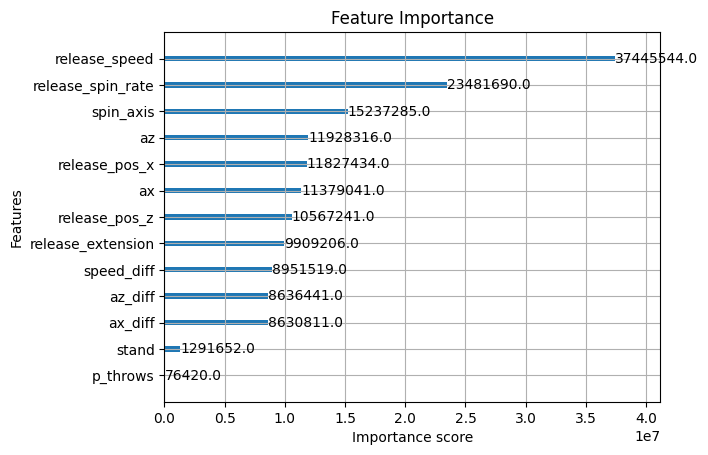

In [16]:
xgb.plot_importance(xgb_model)
plt.title('Feature Importance')
plt.show()

In [17]:
all_data.loc[:, 'y_pred'] = xgb_model.predict(xgb.DMatrix(all_data.loc[:, features], enable_categorical = True))

In [21]:
all_data = calculate_stuff_value(all_data)

In [ ]:
data_2024 = all_data.loc[(all_data['game_date'] > '2024-01-01') & (all_data['game_date'] < '2024-12-31'), :]
data_2023 = all_data.loc[(all_data['game_date'] > '2023-01-01') & (all_data['game_date'] < '2023-12-31'), :]

In [44]:
data_2024_grouped = data_2024.groupby(['pitcher', 'pitch_type']).agg(average_stuff_value = ('stuff_value', 'mean'), pitches = ('release_speed', 'count'))
data_2023_grouped = data_2023.groupby(['pitcher', 'pitch_type']).agg(average_stuff_value = ('stuff_value', 'mean'), pitches = ('release_speed', 'count'))

In [52]:
tmp = data_2024_grouped.reset_index()

In [55]:
min_size = 1000

data_2024_grouped = data_2024_grouped.loc[data_2024_grouped['pitches'] >= min_size, :]
data_2023_grouped = data_2023_grouped.loc[data_2023_grouped['pitches'] >= min_size, :]

In [56]:
data_2023_2024_grouped = pd.merge(data_2023_grouped, data_2024_grouped, how = 'inner', on = 'pitcher', suffixes =  ('_2023', '_2024'))

In [57]:
r2_result = np.power(np.corrcoef(data_2023_2024_grouped['average_stuff_value_2023'].values, data_2023_2024_grouped['average_stuff_value_2024'].values)[0][1], 2)

Text(0.05, 0.9, '$R^2$ = 0.01')

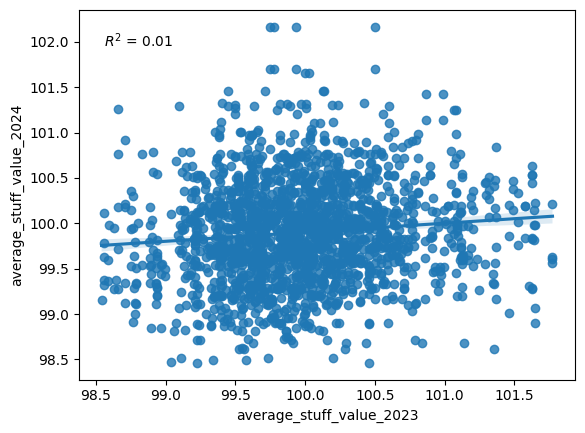

In [58]:
ax = sns.regplot(x = 'average_stuff_value_2023', y = 'average_stuff_value_2024', data = data_2023_2024_grouped)
ax.text(0.05, 0.9, f'$R^2$ = {r2_result:.2f}', transform = ax.transAxes)